# Loan Approval Prediction System
## Enterprise-Grade ML Pipeline with Explainability & Fairness Analysis

## 1. PROBLEM STATEMENT

### Business Context
Financial institutions process thousands of loan applications daily. This ML system automates preliminary credit decisions with:
- **Consistency** - Same criteria applied uniformly
- **Scalability** - Handle volume spikes
- **Explainability** - Transparent decision-making
- **Fairness** - Bias monitoring across demographics

---
## Setup & Imports

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import chi2_contingency, ttest_ind

# ML
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler

# Explainability
import shap

# Utilities
import joblib
import os

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 2. Lets load the data

In [10]:
# Load Data
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f"Training Set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Test Set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")

df = train_df.copy()
df.head(10)

Training Set: 614 rows, 13 columns
Test Set: 367 rows, 12 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [11]:
# Data Schema
schema_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null': df.count(),
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique': df.nunique()
})
print("DATA SCHEMA")
schema_info

DATA SCHEMA


,Data Type,Non-Null,Null Count,Null %,Unique
Loan_ID,object,614,0,0.00,614
Gender,object,601,13,2.12,2
Married,object,611,3,0.49,2
Dependents,object,599,15,2.44,4
Education,object,614,0,0.00,2
Self_Employed,object,582,32,5.21,2
ApplicantIncome,int64,614,0,0.00,505
CoapplicantIncome,float64,614,0,0.00,287
LoanAmount,float64,592,22,3.58,203
Loan_Amount_Term,float64,600,14,2.28,10



Missing values in train:
                  missing_count  missing_pct
Credit_History               50     8.143322
Self_Employed                32     5.211726
LoanAmount                   22     3.583062
Dependents                   15     2.442997
Loan_Amount_Term             14     2.280130
Gender                       13     2.117264
Married                       3     0.488599

Missing values in test:
                  missing_count  missing_pct
Credit_History               29     7.901907
Self_Employed                23     6.267030
Gender                       11     2.997275
Dependents                   10     2.724796
Loan_Amount_Term              6     1.634877
LoanAmount                    5     1.362398


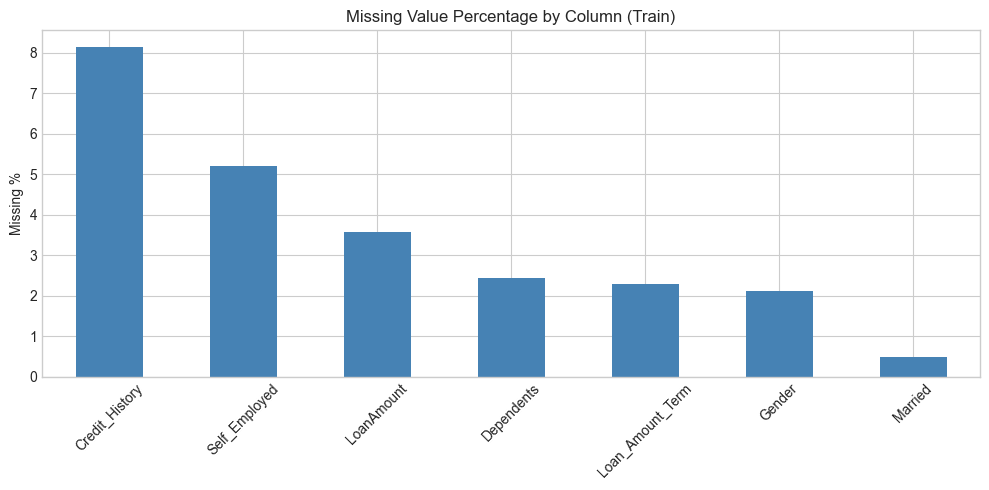

In [12]:
missing_train = train_df.isnull().sum().sort_values(ascending=False)
missing_test = test_df.isnull().sum().sort_values(ascending=False)

missing_train_pct = (train_df.isnull().mean() * 100).sort_values(ascending=False)
missing_test_pct = (test_df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary_train = pd.DataFrame({
    'missing_count': missing_train,
    'missing_pct': missing_train_pct
})

missing_summary_test = pd.DataFrame({
    'missing_count': missing_test,
    'missing_pct': missing_test_pct
})

print('\nMissing values in train:')
print(missing_summary_train[missing_summary_train['missing_count'] > 0])

print('\nMissing values in test:')
print(missing_summary_test[missing_summary_test['missing_count'] > 0])

# Visualize missing percentages in train
plt.figure(figsize=(10, 5))
missing_summary_train[missing_summary_train['missing_count'] > 0]['missing_pct'].plot(kind='bar', color='steelblue')
plt.title('Missing Value Percentage by Column (Train)')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

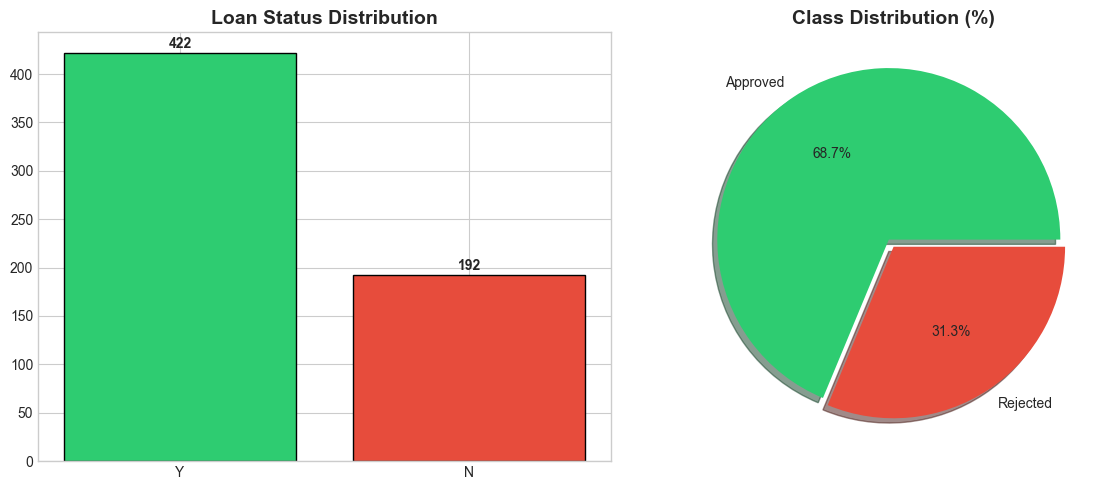


Class Balance: 68.7% Approved, 31.3% Rejected


In [4]:
# Class Balance
target_counts = df['Loan_Status'].value_counts()
target_pct = df['Loan_Status'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(target_pct.values, labels=['Approved', 'Rejected'], autopct='%1.1f%%', 
            colors=colors, explode=(0.05, 0), shadow=True)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClass Balance: {target_pct['Y']:.1f}% Approved, {target_pct['N']:.1f}% Rejected")

---
## 3. EDA & Preprocessing

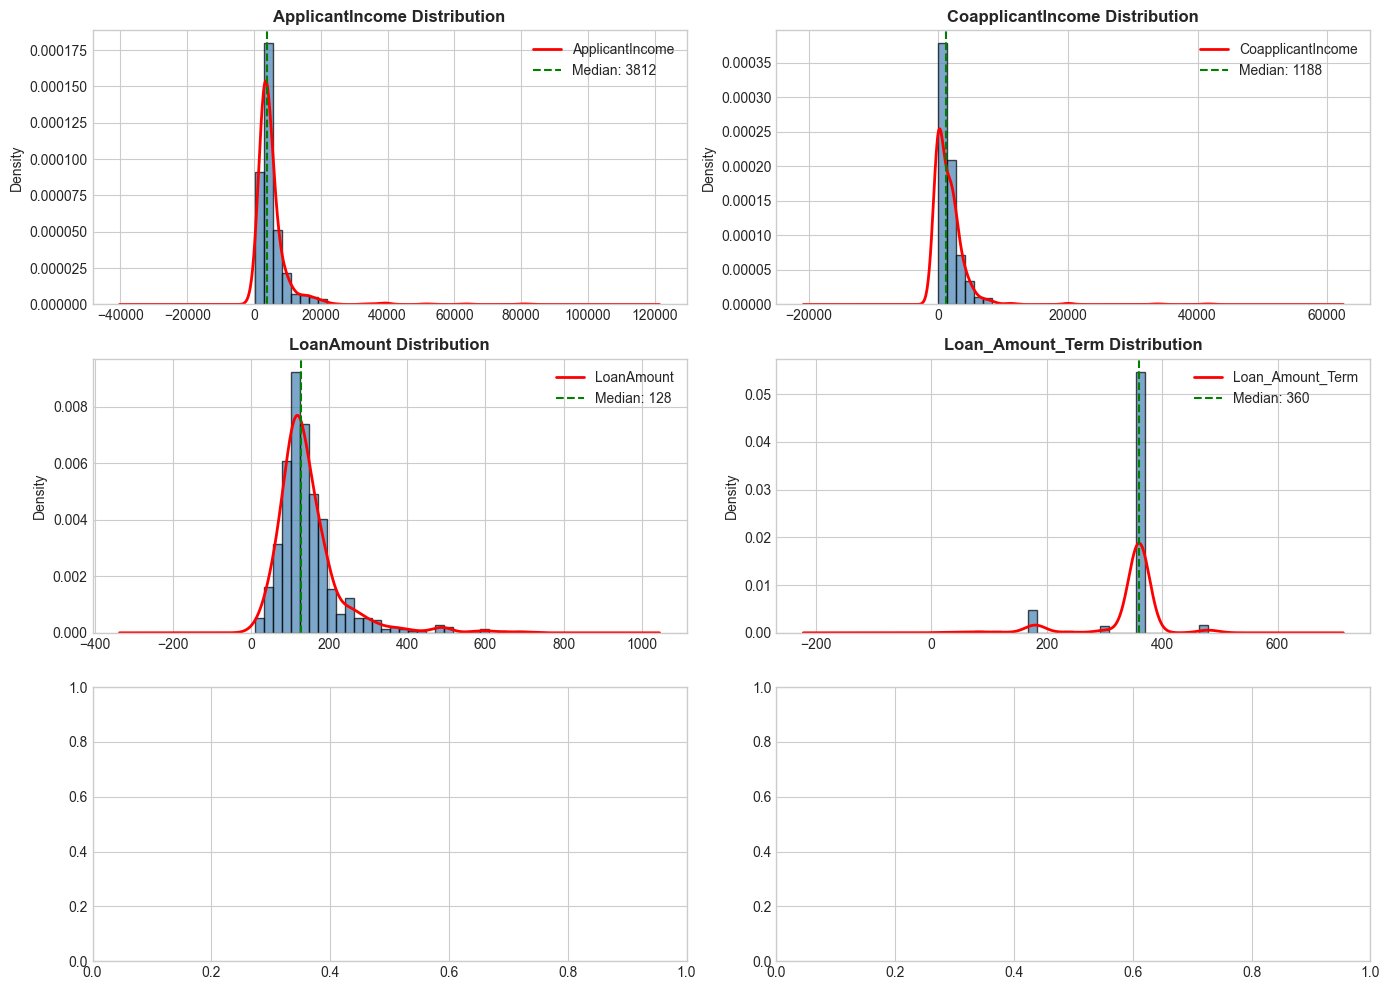

In [ ]:
# Define column types
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Numerical distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 2, idx % 2]
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='black', alpha=0.7, density=True)
    df[col].plot(kind='kde', ax=ax, color='red', linewidth=2)
    ax.axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.0f}')
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.legend()
plt.tight_layout()
plt.show()

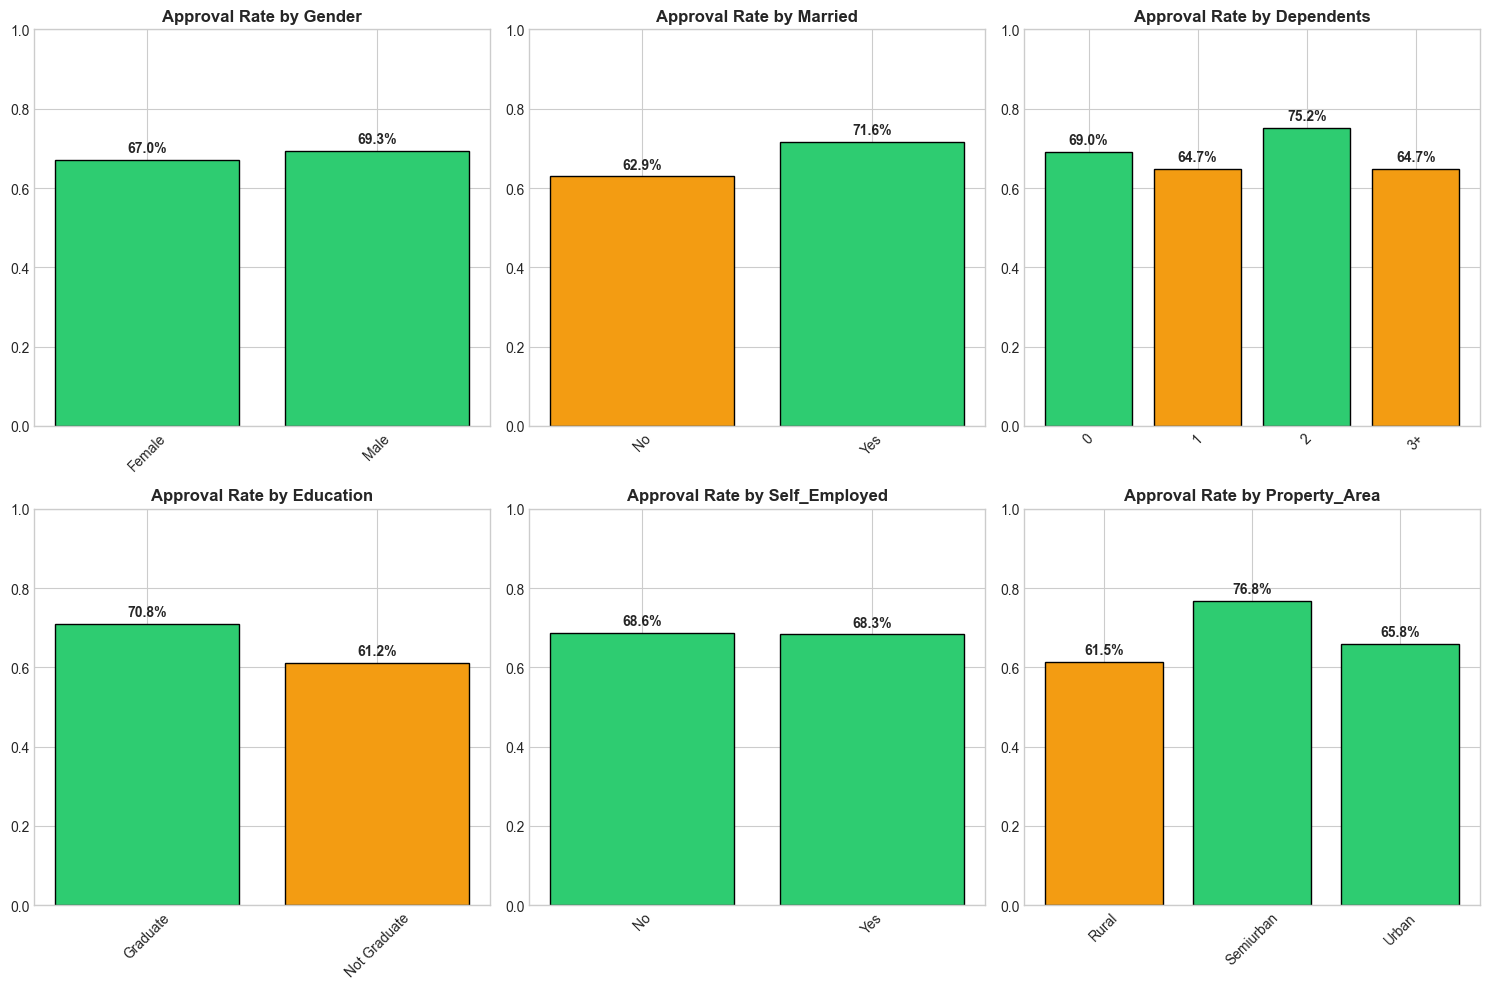

In [14]:
# Approval rate by categorical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    approval_rate = df.groupby(col)['Loan_Status'].apply(lambda x: (x == 'Y').mean())
    colors = ['#2ecc71' if v > 0.65 else '#f39c12' if v > 0.5 else '#e74c3c' for v in approval_rate]
    bars = axes[idx].bar(approval_rate.index.astype(str), approval_rate.values, color=colors, edgecolor='black')
    axes[idx].set_title(f'Approval Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, approval_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

CREDIT HISTORY IMPACT


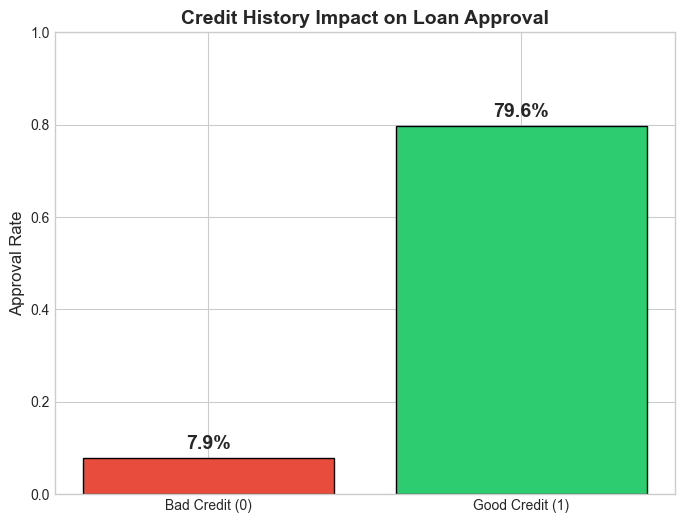


Bad Credit: 7.9% vs Good Credit: 79.6%
Credit History is the MOST IMPORTANT predictor!


In [20]:
# Credit History Impact Analysis
print("CREDIT HISTORY IMPACT")
credit_rates = df.groupby('Credit_History')['Loan_Status'].apply(lambda x: (x == 'Y').mean())

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(['Bad Credit (0)', 'Good Credit (1)'], credit_rates.values, color=colors, edgecolor='black')
ax.set_ylabel('Approval Rate', fontsize=12)
ax.set_title('Credit History Impact on Loan Approval', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
for bar, v in zip(bars, credit_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.1%}', ha='center', fontsize=14, fontweight='bold')
plt.show()

print(f"\nBad Credit: {credit_rates.get(0, 0):.1%} vs Good Credit: {credit_rates.get(1, 0):.1%}")
print("Credit History is the MOST IMPORTANT predictor!")

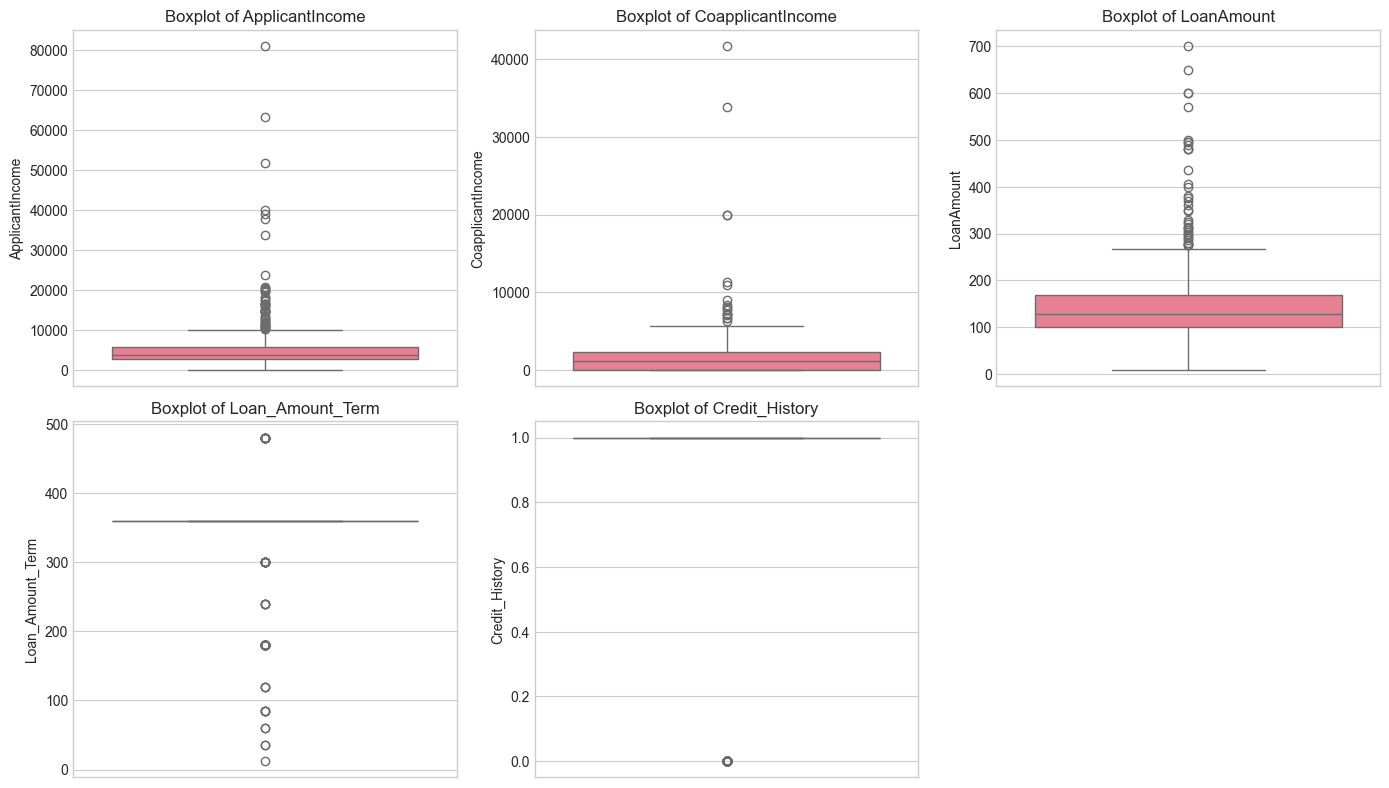

In [22]:
# Boxplots for outlier detection
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=train[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

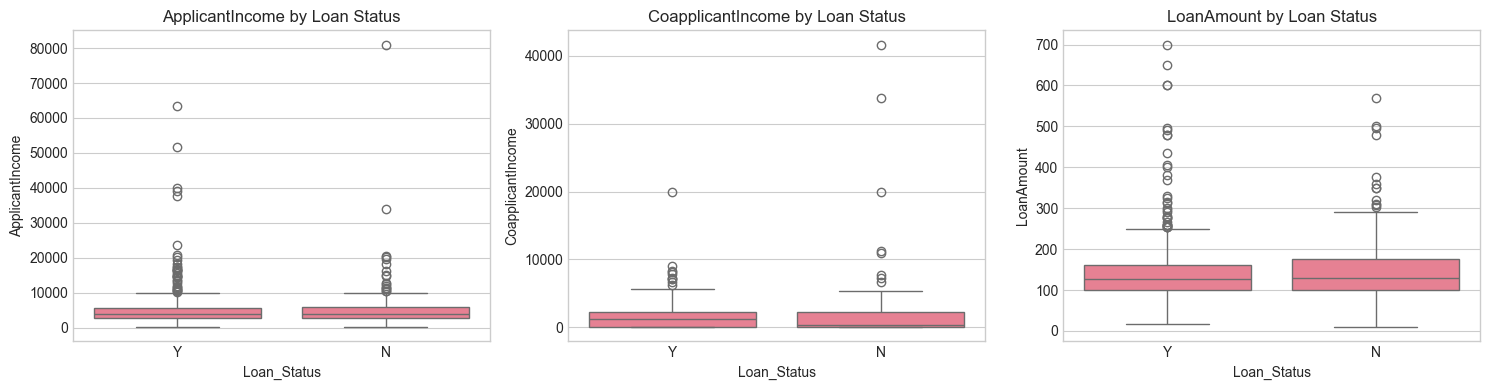

In [28]:
# Target-wise boxplots for key financial features
key_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

plt.figure(figsize=(15, 4))
for i, col in enumerate(key_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=train, x=target_col, y=col)
    plt.title(f'{col} by Loan Status')
plt.tight_layout()
plt.show()


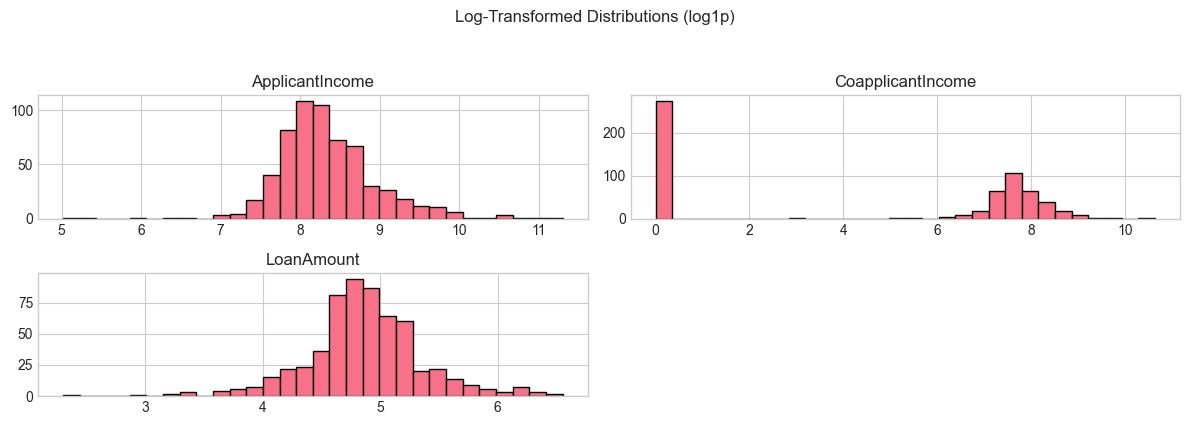

In [31]:
# Log-transform comparison for skewed columns
skewed_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
log_df = train[skewed_cols].copy()
log_df = np.log1p(log_df)

log_df.hist(figsize=(12, 4), bins=30, edgecolor='black')
plt.suptitle('Log-Transformed Distributions (log1p)', y=1.05)
plt.tight_layout()
plt.show()


In [33]:
target_col = 'Loan_Status'
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [35]:
# Include missing values explicitly for EDA readability
train_cat = train_df.copy()
for col in cat_cols:
    train_cat[col] = train_cat[col].fillna('Missing')


In [37]:
print('Categorical value counts:\n')
for col in cat_cols:
    print(f'--- {col} ---')
    print(train_cat[col].value_counts(dropna=False))
    print()

Categorical value counts:

--- Gender ---
Gender
Male       489
Female     112
Missing     13
Name: count, dtype: int64

--- Married ---
Married
Yes        398
No         213
Missing      3
Name: count, dtype: int64

--- Dependents ---
Dependents
0          345
1          102
2          101
3+          51
Missing     15
Name: count, dtype: int64

--- Education ---
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

--- Self_Employed ---
Self_Employed
No         500
Yes         82
Missing     32
Name: count, dtype: int64

--- Property_Area ---
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64



In [39]:
# Approval rate by category
approval_rate_tables = {}
for col in cat_cols:
    table = pd.crosstab(train_cat[col], train_cat[target_col], normalize='index') * 100
    approval_rate_tables[col] = table
    print(f'\nApproval rate table for {col} (% within category):')
    print(table)


Approval rate table for Gender (% within category):
Loan_Status          N          Y
Gender                           
Female       33.035714  66.964286
Male         30.674847  69.325153
Missing      38.461538  61.538462

Approval rate table for Married (% within category):
Loan_Status          N           Y
Married                           
Missing       0.000000  100.000000
No           37.089202   62.910798
Yes          28.391960   71.608040

Approval rate table for Dependents (% within category):
Loan_Status          N          Y
Dependents                       
0            31.014493  68.985507
1            35.294118  64.705882
2            24.752475  75.247525
3+           35.294118  64.705882
Missing      40.000000  60.000000

Approval rate table for Education (% within category):
Loan_Status           N          Y
Education                         
Graduate      29.166667  70.833333
Not Graduate  38.805970  61.194030

Approval rate table for Self_Employed (% within category

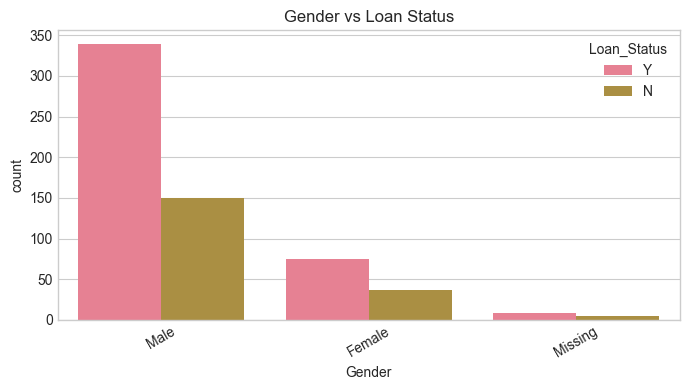

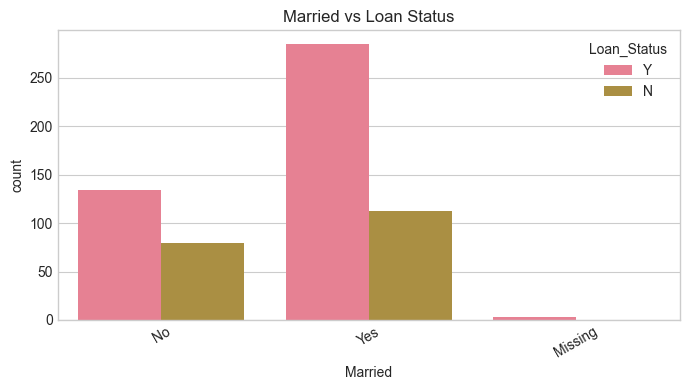

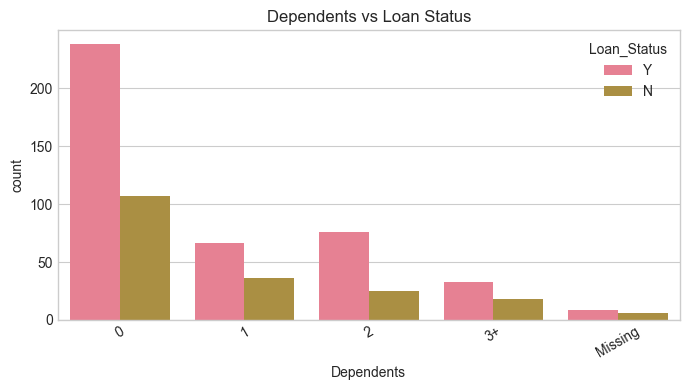

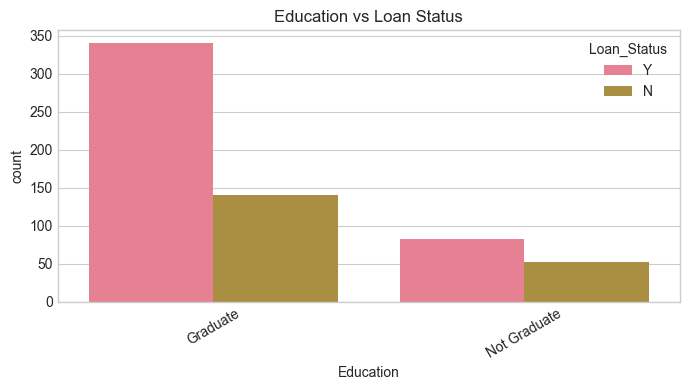

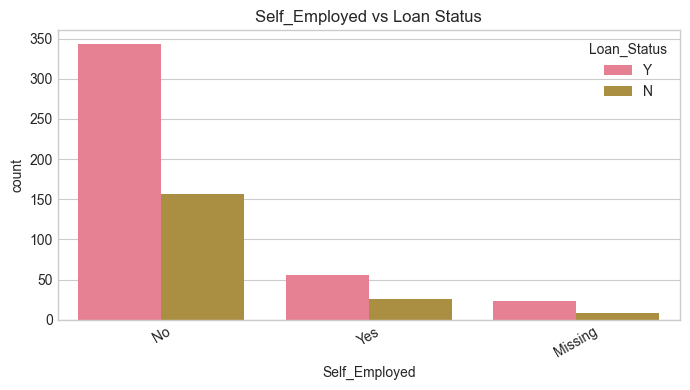

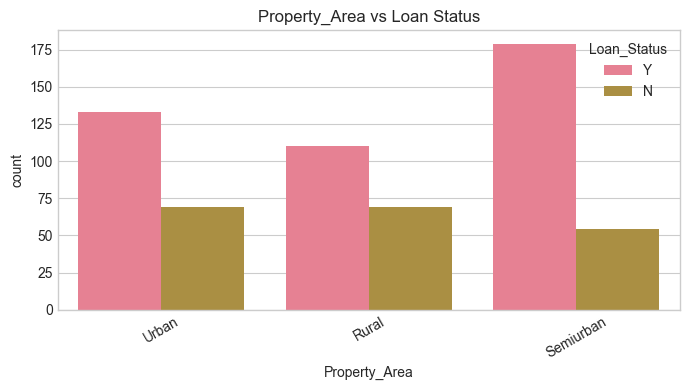

In [41]:
# Count plots with target hue
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=train_cat, x=col, hue=target_col)
    plt.title(f'{col} vs Loan Status')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


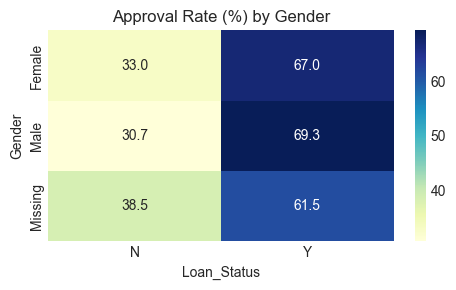

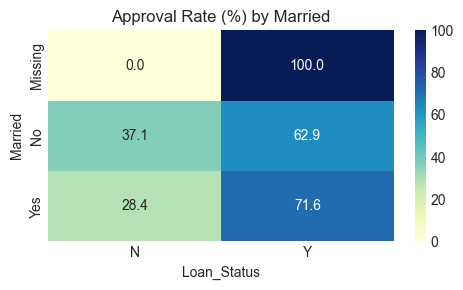

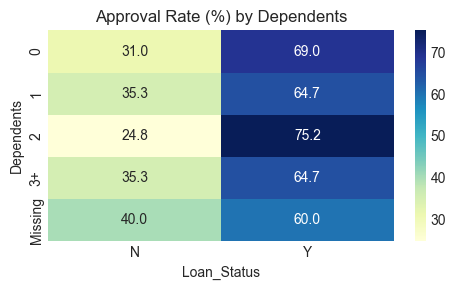

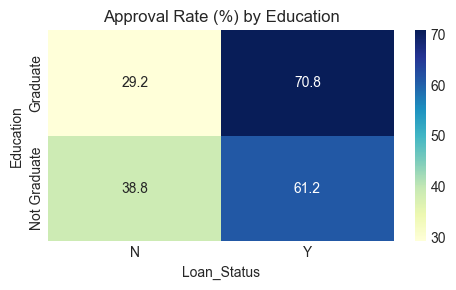

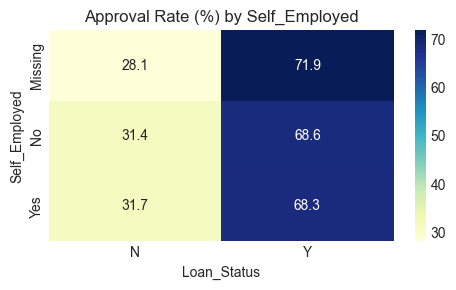

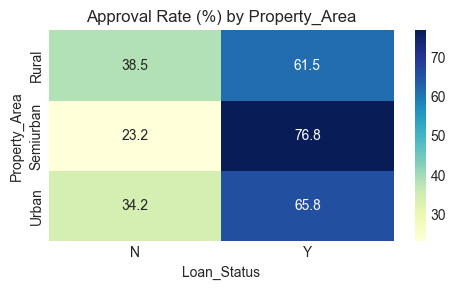

In [43]:
# Heatmap of approval rates
for col in cat_cols:
    table = pd.crosstab(train_cat[col], train_cat[target_col], normalize='index') * 100
    plt.figure(figsize=(5, 3))
    sns.heatmap(table, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title(f'Approval Rate (%) by {col}')
    plt.tight_layout()
    plt.show()


In [46]:
segment_1 = pd.crosstab(
    [train_cat['Education'], train_cat['Property_Area']],
    train_cat[target_col],
    normalize='index'
) * 100

print('\nApproval rate by Education x Property_Area:')
print(segment_1)


Approval rate by Education x Property_Area:
Loan_Status                         N          Y
Education    Property_Area                      
Graduate     Rural          35.877863  64.122137
             Semiurban      22.994652  77.005348
             Urban          30.864198  69.135802
Not Graduate Rural          45.833333  54.166667
             Semiurban      23.913043  76.086957
             Urban          47.500000  52.500000


In [47]:
segment_1 = pd.crosstab(
    [train_cat['Married'], train_cat['Property_Area']],
    train_cat[target_col],
    normalize='index'
) * 100

print('\nApproval rate by Education x Property_Area:')
print(segment_1)


Approval rate by Education x Property_Area:
Loan_Status                    N           Y
Married Property_Area                       
Missing Semiurban       0.000000  100.000000
        Urban           0.000000  100.000000
No      Rural          39.682540   60.317460
        Semiurban      30.000000   70.000000
        Urban          42.857143   57.142857
Yes     Rural          37.931034   62.068966
        Semiurban      19.867550   80.132450
        Urban          29.770992   70.229008


In [48]:
segment_1 = pd.crosstab(
    [train_cat['Dependents'], train_cat['Property_Area']],
    train_cat[target_col],
    normalize='index'
) * 100

print('\nApproval rate by Education x Property_Area:')
print(segment_1)


Approval rate by Education x Property_Area:
Loan_Status                       N          Y
Dependents Property_Area                      
0          Rural          37.614679  62.385321
           Semiurban      20.769231  79.230769
           Urban          36.792453  63.207547
1          Rural          57.142857  42.857143
           Semiurban      27.500000  72.500000
           Urban          31.707317  68.292683
2          Rural          34.482759  65.517241
           Semiurban      16.216216  83.783784
           Urban          25.714286  74.285714
3+         Rural          27.777778  72.222222
           Semiurban      40.000000  60.000000
           Urban          38.461538  61.538462
Missing    Rural          50.000000  50.000000
           Semiurban      33.333333  66.666667
           Urban          42.857143  57.142857


In [45]:
segment_2 = pd.crosstab(
    [train_cat['Married'], train_cat['Dependents']],
    train_cat[target_col],
    normalize='index'
) * 100

print('\nApproval rate by Married x Dependents:')
print(segment_2)


Approval rate by Married x Dependents:
Loan_Status                 N           Y
Married Dependents                       
Missing Missing      0.000000  100.000000
No      0           35.672515   64.327485
        1           43.478261   56.521739
        2           37.500000   62.500000
        3+          42.857143   57.142857
        Missing     50.000000   50.000000
Yes     0           26.436782   73.563218
        1           32.911392   67.088608
        2           23.655914   76.344086
        3+          34.090909   65.909091
        Missing     50.000000   50.000000


Correlation matrix:
                    ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome            1.000000          -0.116605    0.570909   
CoapplicantIncome         -0.116605           1.000000    0.188619   
LoanAmount                 0.570909           0.188619    1.000000   
Loan_Amount_Term          -0.045306          -0.059878    0.039447   
Credit_History            -0.014715          -0.002056   -0.008433   
Loan_Status_Binary        -0.004710          -0.059187   -0.037318   

                    Loan_Amount_Term  Credit_History  Loan_Status_Binary  
ApplicantIncome            -0.045306       -0.014715           -0.004710  
CoapplicantIncome          -0.059878       -0.002056           -0.059187  
LoanAmount                  0.039447       -0.008433           -0.037318  
Loan_Amount_Term            1.000000        0.001470           -0.021268  
Credit_History              0.001470        1.000000            0.561678  
Loan_Status_Binary         -0.021268   

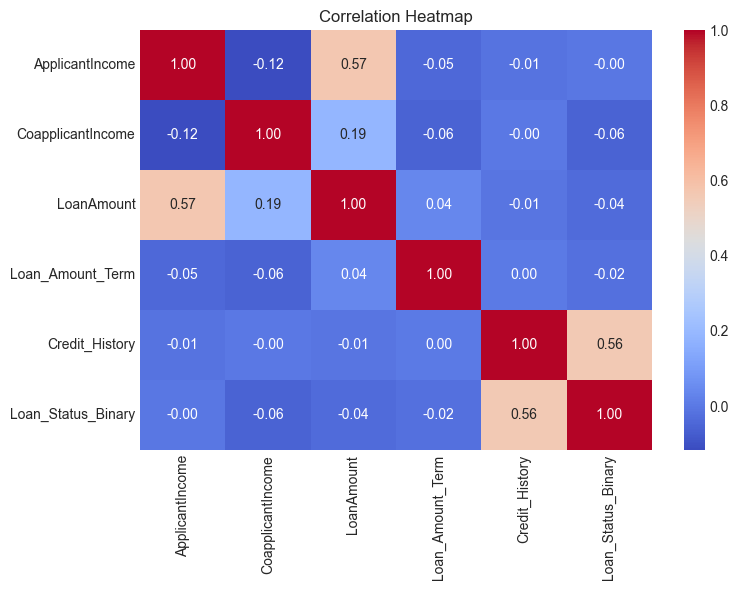

In [54]:
target_col = 'Loan_Status'
train['Loan_Status_Binary'] = train[target_col].map({'N': 0, 'Y': 1})

numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status_Binary']
corr = train[numeric_cols].corr()
print('Correlation matrix:')
print(corr)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


Numeric feature means by Loan_Status:
             ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
Loan_Status                                                                     
N                5446.078125        1877.807292  151.220994        344.064516   
Y                5384.068720        1504.516398  144.294404        341.072464   

             Credit_History  
Loan_Status                  
N                  0.541899  
Y                  0.981818  

Numeric feature medians by Loan_Status:
             ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
Loan_Status                                                                     
N                     3833.5              268.0       129.0             360.0   
Y                     3812.5             1239.5       126.0             360.0   

             Credit_History  
Loan_Status                  
N                       1.0  
Y                       1.0  


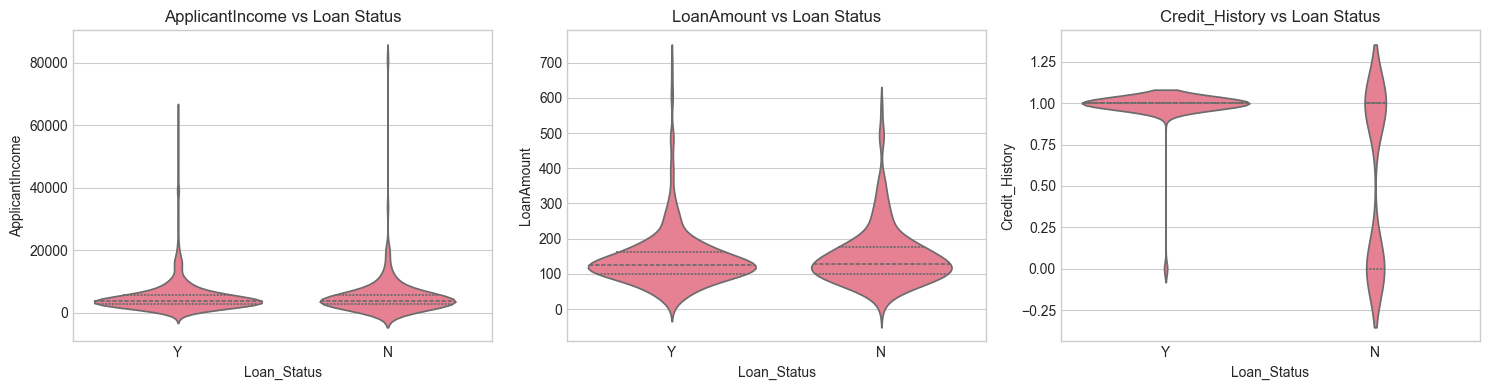

In [56]:
print('\nNumeric feature means by Loan_Status:')
print(train.groupby(target_col)[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']].mean())

print('\nNumeric feature medians by Loan_Status:')
print(train.groupby(target_col)[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']].median())

# Violin/box style comparisons for key numeric features
key_num_cols = ['ApplicantIncome', 'LoanAmount', 'Credit_History']

plt.figure(figsize=(15, 4))
for i, col in enumerate(key_num_cols, 1):
    plt.subplot(1, 3, i)
    sns.violinplot(data=train, x=target_col, y=col, inner='quartile')
    plt.title(f'{col} vs Loan Status')
plt.tight_layout()
plt.show()

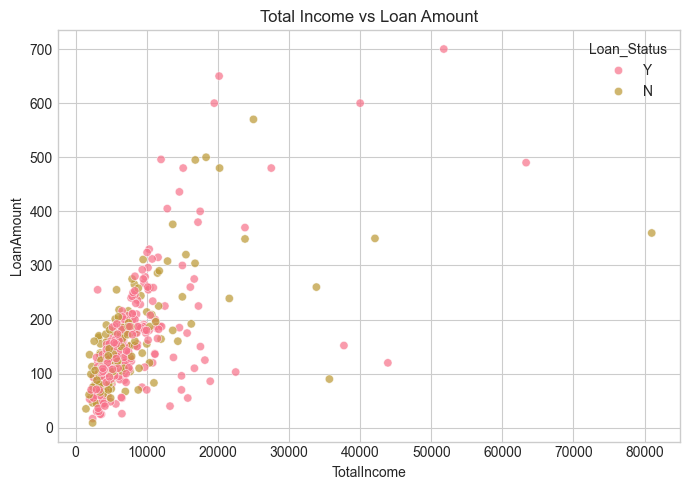

In [57]:
train['TotalIncome'] = train['ApplicantIncome'] + train['CoapplicantIncome']

plt.figure(figsize=(7, 5))
sns.scatterplot(data=train, x='TotalIncome', y='LoanAmount', hue=target_col, alpha=0.7)
plt.title('Total Income vs Loan Amount')
plt.tight_layout()
plt.show()

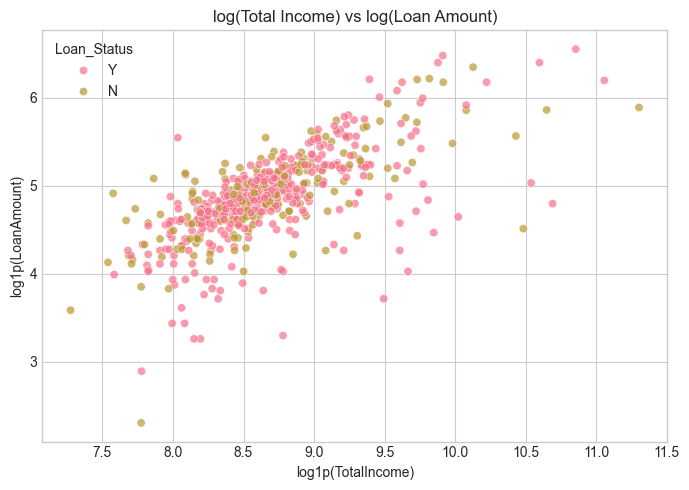

In [58]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=train, x=np.log1p(train['TotalIncome']), y=np.log1p(train['LoanAmount']), hue=train[target_col], alpha=0.7)
plt.title('log(Total Income) vs log(Loan Amount)')
plt.xlabel('log1p(TotalIncome)')
plt.ylabel('log1p(LoanAmount)')
plt.tight_layout()
plt.show()



Approval rate by Credit_History:
Loan_Status             N          Y
Credit_History                      
-1.0            26.000000  74.000000
 0.0            92.134831   7.865169
 1.0            20.421053  79.578947


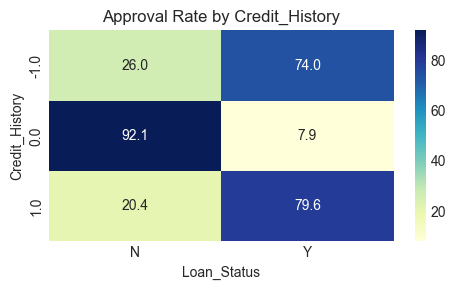

In [59]:
# Approval rate by Credit_History
credit_table = pd.crosstab(train['Credit_History'].fillna(-1), train[target_col], normalize='index') * 100
print('\nApproval rate by Credit_History:')
print(credit_table)

plt.figure(figsize=(5, 3))
sns.heatmap(credit_table, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Approval Rate by Credit_History')
plt.tight_layout()
plt.show()

In [60]:
# Simple IQR-based outlier counts
outlier_summary = []
for col in numeric_cols:
    s = train[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        'feature': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outliers,
        'outlier_pct': round(outliers / len(s) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(by='outlier_pct', ascending=False)
print('\nIQR-based outlier summary:')
print(outlier_summary)


IQR-based outlier summary:
              feature      q1       q3      iqr  lower_bound  upper_bound  \
4      Credit_History     1.0     1.00     0.00        1.000        1.000   
3    Loan_Amount_Term   360.0   360.00     0.00      360.000      360.000   
0     ApplicantIncome  2877.5  5795.00  2917.50    -1498.750    10171.250   
2          LoanAmount   100.0   168.00    68.00       -2.000      270.000   
1   CoapplicantIncome     0.0  2297.25  2297.25    -3445.875     5743.125   
5  Loan_Status_Binary     0.0     1.00     1.00       -1.500        2.500   

   outlier_count  outlier_pct  
4             89        15.78  
3             88        14.67  
0             50         8.14  
2             39         6.59  
1             18         2.93  
5              0         0.00  


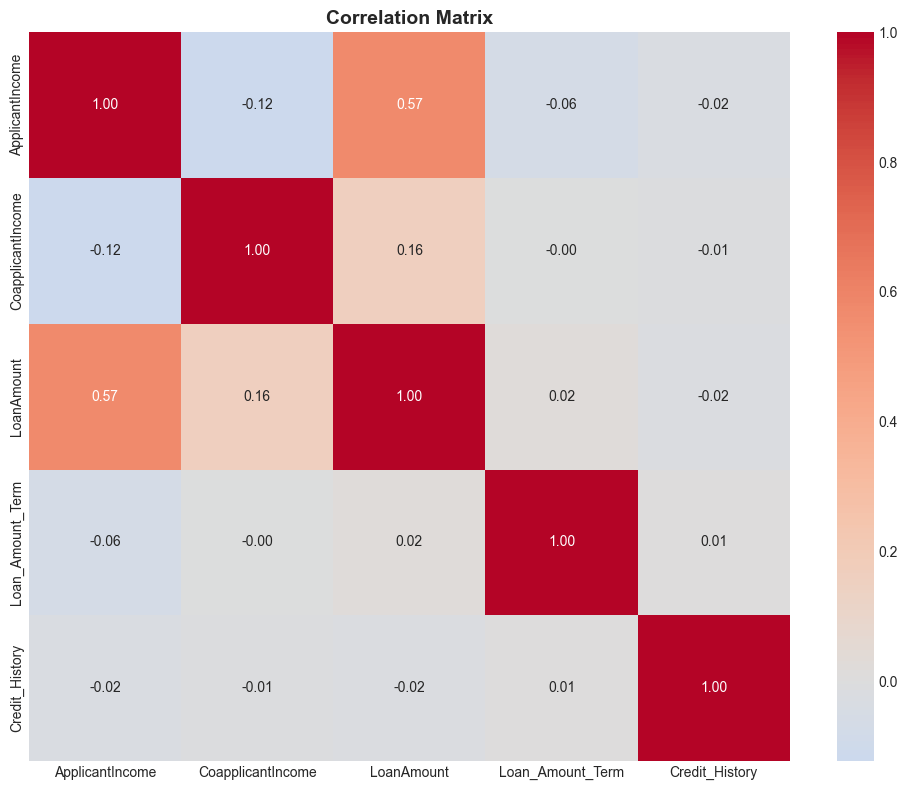

In [61]:
# Correlation Heatmap
df_numeric = df[numerical_cols + ['Credit_History']].dropna()
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.2f')
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
# Cramér's V for Categorical Correlations
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k-1, r-1))

print("CRAMÉR'S V (Categorical Correlations)")
print("="*50)
for col in categorical_cols:
    if df[col].notna().sum() > 0:
        cv = cramers_v(df[col].dropna(), df.loc[df[col].notna(), 'Loan_Status'])
        strength = "Strong" if cv > 0.3 else ("Moderate" if cv > 0.1 else "Weak")
        print(f"  {col}: {cv:.3f} ({strength})")

CRAMÉR'S V (Categorical Correlations)
  Gender: 0.015 (Weak)
  Married: 0.086 (Weak)
  Dependents: 0.073 (Weak)
  Education: 0.082 (Weak)
  Self_Employed: 0.000 (Weak)
  Property_Area: 0.142 (Moderate)


---
## 4. MISSING VALUE & OUTLIER TREATMENT

In [ ]:
# Missing Value Analysis
print("MISSING VALUES")
missing = df.isnull().sum()
missing = missing[missing > 0]
for col, count in missing.items():
    print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")

# Imputation
print("\nIMPUTING MISSING VALUES")
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  {col}: median={median_val:.0f}")

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  {col}: mode='{mode_val}'")

print(f"\nRemaining nulls: {df.isnull().sum().sum()}")

LOG TRANSFORMATIONS
  Applied log1p to income and loan features


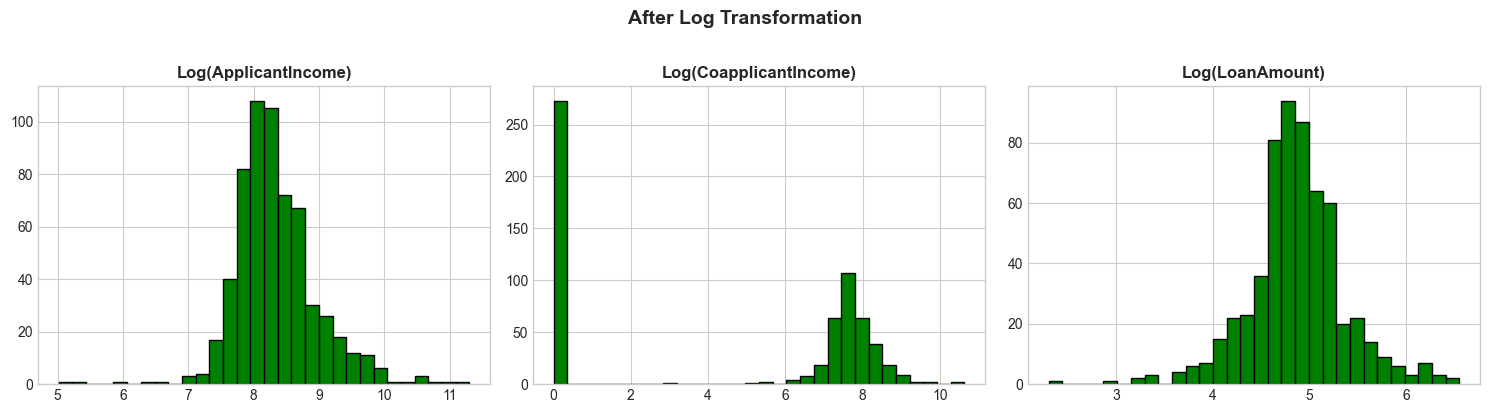

In [64]:
# Log Transformations
print("LOG TRANSFORMATIONS")
df['Log_ApplicantIncome'] = np.log1p(df['ApplicantIncome'])
df['Log_CoapplicantIncome'] = np.log1p(df['CoapplicantIncome'])
df['Log_LoanAmount'] = np.log1p(df['LoanAmount'])
print("  Applied log1p to income and loan features")

# Compare distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['Log_ApplicantIncome'], bins=30, color='green', edgecolor='black')
axes[0].set_title('Log(ApplicantIncome)', fontweight='bold')
axes[1].hist(df['Log_CoapplicantIncome'], bins=30, color='green', edgecolor='black')
axes[1].set_title('Log(CoapplicantIncome)', fontweight='bold')
axes[2].hist(df['Log_LoanAmount'], bins=30, color='green', edgecolor='black')
axes[2].set_title('Log(LoanAmount)', fontweight='bold')
plt.suptitle('After Log Transformation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. FEATURE ENGINEERING

In [65]:
print("FEATURE ENGINEERING")
print("="*50)

# Total Income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Log_Total_Income'] = np.log1p(df['Total_Income'])
print("Total_Income created")

# Dependents numeric
df['Dependents_Numeric'] = df['Dependents'].replace('3+', '3').astype(float)

# Income per dependent
df['Income_Per_Dependent'] = df['Total_Income'] / (df['Dependents_Numeric'] + 1)
print("Income_Per_Dependent created")

# Loan to Income Ratio
df['Loan_to_Income'] = df['LoanAmount'] / (df['Total_Income'] / 1000 + 1)
print("Loan_to_Income created")

# Debt to Income
df['Estimated_EMI'] = (df['LoanAmount'] * 1000 * 0.01 * 
                        (1.01 ** df['Loan_Amount_Term']) / 
                        ((1.01 ** df['Loan_Amount_Term']) - 1))
df['Debt_to_Income'] = df['Estimated_EMI'] / (df['Total_Income'] + 1)
print("Debt_to_Income created")

# Credit History Interactions
df['CreditHistory_Income'] = df['Credit_History'] * df['Log_Total_Income']
df['CreditHistory_Loan'] = df['Credit_History'] * df['Log_LoanAmount']
print("Credit History interactions created")

# Property Area
area_map = {'Rural': 1, 'Semiurban': 2, 'Urban': 3}
df['Property_Area_Encoded'] = df['Property_Area'].map(area_map)
df['Area_Income_Interaction'] = df['Property_Area_Encoded'] * df['Log_Total_Income']
print("Area_Income_Interaction created")

# Binary encodings
df['Gender_Encoded'] = (df['Gender'] == 'Male').astype(int)
df['Married_Encoded'] = (df['Married'] == 'Yes').astype(int)
df['Education_Encoded'] = (df['Education'] == 'Graduate').astype(int)
df['Self_Employed_Encoded'] = (df['Self_Employed'] == 'Yes').astype(int)
df['Graduate_SelfEmployed'] = ((df['Education'] == 'Graduate') & (df['Self_Employed'] == 'Yes')).astype(int)
print("Binary encodings created")

# One-hot Property Area
df = pd.get_dummies(df, columns=['Property_Area'], prefix='PropArea')
print("One-hot Property_Area created")

# Family Size
df['Family_Size'] = df['Dependents_Numeric'] + df['Married_Encoded'] + 1
print("Family_Size created")

# Target
df['Loan_Status_Encoded'] = (df['Loan_Status'] == 'Y').astype(int)

print(f"\nTotal features: {df.shape[1]}")

FEATURE ENGINEERING
Total_Income created
Income_Per_Dependent created
Loan_to_Income created
Debt_to_Income created
Credit History interactions created
Area_Income_Interaction created
Binary encodings created
One-hot Property_Area created
Family_Size created

Total features: 36



### 1) Why should you be cautious when interpreting Pearson correlation in this dataset?

Because Pearson correlation only captures __linear numeric relationships__ and is sensitive to outliers, skewness, and distribution shape. This dataset contains skewed financial variables, possible nonlinear effects, and important categorical features, so correlation should be treated as a rough signal, not a final conclusion.

### 2) If `Credit_History` has the highest correlation with `Loan_Status_Binary`, does that mean we can ignore the other features?

No. A dominant feature does not make the rest useless. Other features can provide incremental predictive value, interaction effects, robustness when `Credit_History` is missing, and better generalization.

### 3) Why is `TotalIncome` often a better engineered feature than keeping applicant and coapplicant income fully separate?

Because it better captures __overall household repayment capacity__, which is closer to the business problem. It can also reduce noise from treating both income sources independently.

### 4) If mean differs a lot between `Y` and `N` but median does not, what does that suggest?

It suggests the difference may be driven by __outliers or a long tail__, not by a broad class-wide shift. In other words, a few extreme values are affecting the average.

### 5) Top 5 EDA conclusions

1. `Credit_History` is likely the strongest predictor of loan approval.
2. `ApplicantIncome`, `CoapplicantIncome`, and `LoanAmount` are heavily right-skewed and contain extreme but potentially valid values.
3. Missing values exist in operationally important fields and must be handled systematically.
4. `TotalIncome` is a strong candidate engineered feature because it reflects household repayment capacity.
5. Categorical variables such as `Property_Area`, `Education`, and perhaps `Married` show signal, but likely weaker than credit history.

### 3 preprocessing decisions before modeling

1. __Impute missing values__ carefully:

   - categorical: mode or explicit missing category,
   - numeric: median,
   - possibly add missing indicators for important variables like `Credit_History`.

2. __Encode categorical variables__ consistently:

   - one-hot encoding for nominal categories,
   - optionally ordinal handling for `Dependents`.

3. __Transform skewed financial variables__ where appropriate:
   - consider `log1p` for `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, and maybe engineered `TotalIncome`, especially for linear/logistic models.
